# Housing Unit Allocation with Person Record File Full Workflow

## Overview
This code works with the National Structures Inventory to run the housing unit allocation (HUA) and the person record file (PREC) workflow.
The HUA process is generalizable to any county in the United States. The HUA process will work for any file that has locations of structures and some basic information about the buildings.
The process is designed to work with [IN-CORE](https://incore.ncsa.illinois.edu/), a community resilience modeling environment.
Using IN-CORE requires an account and access to the IN-CORE Dataservice.

Functions are provided to obtain and clean data required for the version 2 Housing Unit Allocation. 

## Required Inputs

Program requires the following inputs:

If using the National Structures Inventory there are no required inputs.

[Census API KEY *REQUIRED*](CENSUS_API_KEY.md) See CENSUS_API_KEY.md file for more details.
    
## Output Description
The output of this workflow is a CSV file with the housing unit inventory allocated to a building inventory using the housing unit allocation model.

The output CSV is designed to be used in the Interdependent Networked Community Resilience Modeling Environment (IN-CORE).

IN-CORE is an open source python package that can be used to model the resilience of a community. To download IN-CORE, see:

https://incore.ncsa.illinois.edu/


## Instructions
Users can run the workflow by executing each block of code in the notebook.

## Description of Program
- program:    ncoda_07fv3_HUA_PREC_NSI
- task:       Start with NSI building inventory, run housing unit allocation algorithm, and then run person record file algorithm
- See github commits for description of program updates
- Current Version: v3 - 
- 2024-02-20 - Combine code from 07c, 07d, and 07e into one notebook
- 2024-05-22 - removed the drop down menu, did not work consistently
- 2025-02-21 - Test with 2020 HUI
- 2025-03-07 - Update to version 2 to differentiate running 2010 and 2020
- 2025-03-27 - V3 Solved issue for states starting with 0 FIPS code - major modification to code
- 2026-05-23 - v2.2.0 improvements and API Key required
- project:    Interdependent Networked Community Resilience Modeling Environment (IN-CORE), Subtask 5.2 - Social Institutions
- funding:	  NIST Financial Assistance Award Numbers: 70NANB15H044 and 70NANB20H008
- funding:	  Southeast Texas Urban Integrated Field Lab Department of Energy DE-SC0023216 
- author:     Nathanael Rosenheim

## Required Citations:
Rosenheim, Nathanael, Roberto Guidotti, Paolo Gardoni & Walter Gillis Peacock. (2021). Integration of detailed household and housing unit characteristic data with critical infrastructure for post-hazard resilience modeling. _Sustainable and Resilient Infrastructure_. 6(6), 385-401. https://doi.org/10.1080/23789689.2019.1681821

Rosenheim, Nathanael (2021) “Detailed Household and Housing Unit Characteristics: Data and Replication Code.” _DesignSafe-CI_. 
https://doi.org/10.17603/ds2-jwf6-s535.

In [19]:
# To reload submodules need to use this magic command to set autoreload on
%load_ext autoreload
%autoreload 2
from pyncoda.ncoda_00g_community_options import *
from IPython.display import display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### How to set up the Community Dictionary
Please review the python code in the file pyncoda/ncoda_00g_community_options.py

In this file you will find a collection of data dictionaries with various ways to setup the inputs for the Housing Unit Allocation process. 

The basic dictionary includes the name of the community, the county FIPS code, your input building inventory file, and key variables in the building inventory file.

In [20]:
# select a community from this list
# if your community is not in this list, add it to the file ncoda_00g_community_options.py
list_community_options(communities_dictionary)

['Lumberton, NC: IN-CORE Building inventory for Robeson County, NC',
 'Galveston, TX: IN-CORE Building inventory for Galveston County, TX',
 'Galveston, TX: NSI Building inventory for Galveston County, TX',
 'Galveston, TX: IN-CORE Building inventory for Galveston Island, TX',
 'Mayfield, KY: NSI Building inventory for Graves County, KY',
 'Beaumont, TX: NSI Building inventory for Jefferson County, TX',
 'Beaumont, TX: Safayet Building inventory for Jefferson County, TX',
 'Pentwater, MI: NSI Building inventory for Oceana County, MI',
 'Seaside, OR: NSI Building inventory for Clatsop County, OR',
 'Lane County, OR: NSI Building inventory for Lane County, OR',
 'Benton County, OR: NSI Building inventory for Benton County, OR',
 'Southeast Texas Urban Integrated Field Lab: NSI Building inventory for Southeast Texas',
 'Southeast Texas Urban Integrated Field Lab (12 neighbor counties): NSI Building inventory for Southeast Texas',
 'Brazos County, TX: NSI Building inventory for Brazos Coun

In [21]:
community_id_by_name =  'Mayfield, KY: NSI Building inventory for Graves County, KY'

In [22]:
community_id, focalplace, countyname, countyfips = get_community_id_by_name(community_id_by_name)
communities = {community_id : communities_dictionary[community_id]}

Selected community ID: Mayfield_KY
Mayfield, KY is in KENTUCKY
Focal place: Mayfield
Mayfield, KY is in Graves County, KY with FIPS code 21083
Use IN-CORE: False


## Setup Python Environment

In [23]:
import pandas as pd
import geopandas as gpd # For reading in shapefiles
import numpy as np
import sys # For displaying package versions
import os # For managing directories and file paths if drive is mounted
import scooby # Reports Python environment

import contextily as cx # For adding basemap tiles to plot
import matplotlib.pyplot as plt # For plotting and making graphs

In [24]:
# open, read, and execute python program with reusable commands
from pyncoda.ncoda_00d_cleanvarsutils import *
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_07i_process_communities import process_community_workflow

In [25]:
# Generate report of Python environment
base_packages = ['pandas','ipyleaflet','seaborn','contextily']
incore_packages = ['pyincore','pyincore_viz']
check_packages = base_packages + incore_packages
print(scooby.Report(additional=check_packages))


--------------------------------------------------------------------------------
  Date: Sat May 23 17:54:45 2026 Eastern Daylight Time

                OS : Windows (10 10.0.26200 SP0 Multiprocessor Free)
            CPU(s) : 16
           Machine : AMD64
      Architecture : 64bit
               RAM : 31.7 GiB
       Environment : Jupyter

  Python 3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50)
  [MSC v.1916 64 bit (AMD64)]

            pandas : 2.2.2
        ipyleaflet : Module not found
           seaborn : 0.13.2
        contextily : 1.6.0
          pyincore : Module not found
      pyincore_viz : Module not found
             numpy : 1.26.4
             scipy : 1.13.1
           IPython : 8.25.0
        matplotlib : 3.8.4
            scooby : 0.10.0

  Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303
  for Intel(R) 64 architecture applications
--------------------------------------------------------------------------------


In [26]:
# Check working directory - good practice for relative path access
os.getcwd()

'c:\\Users\\nathanael99\\MyProjects\\GitHub\\intersect-community-data'

## Run Housing Unit Allocation
The following code will produce the following outputs:
1. Housing Unit Inventory
2. Address Point Inventory
3. Housing Unit Allocation

In [27]:
basevintage_options = ['2010','2020']
# basevintage_options = ['2010']

Generating Housing Unit Inventory v2-2-0 data for Mayfield, KY
Graves County, KY : county FIPS Code 21083
File already exists, skipping: OutputData/Mayfield_KY/../hui_v2-2-0_Mayfield_KY_2010_rs9876.csv
Checking output for huid
Checking output for blockid
Checking output for bgid
Checking output for tractid
Checking output for FIPScounty
Checking output for numprec
Checking output for ownershp
Checking output for race
Checking output for hispan
Checking output for family
Checking output for vacancy
Checking output for gqtype
Checking output for incomegroup
Checking output for hhinc
Checking output for randincome
Checking output for poverty
Checking huid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
Checking blockid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
    Length of blockid is correct
Checking bgid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
  

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:475: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_groups[self.new_char] = merged_groups[self.new_char].\


After update observations geovar flag set 1 = 9695
    Check random merge results for primary data.
Check by geovar flag family_Tract2020_flagsetrm
Observations flag not equal to 0 9695
Input and output data have the same length 14805
Outputdata has 9695 Observations with predicted family
Percent left to predict: 34.52
    Overwrite input data with update output data.
Flag vars available ['family_flagsetrm', 'family_Tract2020_flagsetrm']
Before update output_df observations flag set 1 = 0
Before update results observations flag set 1 = 9695
After update observations geovar flag set 1 = 9695
    Check random merge results for secondary data.
Check by geovar flag family_Tract2020_flagsetrm
Observations flag not equal to 0 9695
Input and output data have the same length 9896
Outputdata has 9695 Observations with predicted family
Percent left to predict:  2.03
    Overwrite input data with update output data.

+++++++++++++++++++++++++++++++++++++++
Percent left to predict:  34.515366

+++

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


All
    Random Merge primary with secondary by All
Check merge vars includes geovarid: ['County2020', 'race', 'hispan', 'incomegroup', 'random_mergeorder']
Primary data frame has extra family  observations with no match: 4909
Observations with no match filled with 0
Merge found extra family  observations: 0
    Set Flags after Merge
['uniqueidB19001', 'County2020', 'race', 'hispan', 'incomegroup', 'random_mergeorder', 'uniqueidB19101', 'family', 'check_merge', 'family_flagsetrm', 'family_Tract2020_flagsetrm', 'family_County2020_flagsetrm']
Observations without primary flag set 4909
Observations without geovar flag set 4909
After updated observations without geovar flag set 4909
Round = 3
Setting 0 flags for observations set by random merge using both primary and secondary data.
Setting 0 flags for observations set by random merge using only primary data.
0 observations do not have required variable County2020
0 observations do not have required variable race
0 observations do not have 

...

EPSG 4269 is the current projection
Spatially Join place Columns ['GEOID', 'NAME', 'NAMELSAD'] with Block Data.
Polygon file has 555 place polygons.
Identified 10 place polygons to spatially join.
Spatially Join puma Columns ['GEOID20', 'NAMELSAD20'] with Block Data.
Polygon file has 35 puma polygons.
Identified 1 puma polygons to spatially join.
Checking Column Names for ['GEOID', 'NAME', 'NAMELSAD'] in puma data
Column GEOID is not correctly formatted
Changing column name to placeGEOID20
Column NAME is not correctly formatted
Changing column name to placeNAME20
Column NAMELSAD is not correctly formatted
Changing column name to placeNAMELSAD20
Column GEOID is correctly formatted
Column NAME is not correctly formatted
Column name should be pumaNAME20
Please check column names in puma data
Column NAMELSAD is correctly formatted
***************
Predicting Housing Unit Estimates
***************

Dropping observations where geometry is null
Number of observations dropped:  0
Building Inven

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\ncoda_00e_geoutilities.py:310: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2180832' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  copy_point_gdf.loc[precise_matches.index,geolevel+col] = polygon[col]
c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\ncoda_00e_geoutilities.py:310: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Water Valley' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  copy_point_gdf.loc[precise_matches.index,geolevel+col] = polygon[col]


....................Using residential archetypes for residential unit estimates
11522 Buildings have Residential Archetype RES1-1SNB
959 Buildings have Residential Archetype RES1-1SWB
1764 Buildings have Residential Archetype RES1-2SNB
817 Buildings have Residential Archetype RES1-2SWB
306 Buildings have Residential Archetype RES1-3SNB
224 Buildings have Residential Archetype RES1-3SWB
0 Buildings have Residential Archetype RES1-SLNB
0 Buildings have Residential Archetype RES1-SLWB
0 Buildings have Residential Archetype RES1
1898 Buildings have Residential Archetype RES2
436 Buildings have Residential Archetype RES3A
53 Buildings have Residential Archetype RES3B
14 Buildings have Residential Archetype RES3C
10 Buildings have Residential Archetype RES3D
0 Buildings have Residential Archetype RES3E
1 Buildings have Residential Archetype RES3F
5 Buildings have Residential Archetype RES4
0 Buildings have Residential Archetype RES5
12 Buildings have Residential Archetype RES6
17 Buildings h

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\ncoda_07d_run_hua_workflow.py:173: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  addptv2_df.loc[condition1 & condition2 & condition3,'ownershp1'] \


NA
    Random Merge primary with secondary by NA
Check merge vars includes geovarid: ['Block2020', 'huicounter3', 'ownershp1', 'random_mergeorder']
Primary data frame has extra strctid  observations with no match: 2431
Observations with no match filled with -999
Merge found extra strctid  observations: 12435
    Set Flags after Merge
['huid', 'Block2020', 'huicounter3', 'ownershp1', 'random_mergeorder', 'addptid', 'strctid', 'addrptid', 'fd_id_bid', 'huestimate', 'huicounter_addpt', 'placeNAME20', 'x', 'y', 'check_merge', 'strctid_flagsetrm', 'strctid_Block2020_flagsetrm']
Observations without primary flag set 14866
Observations without geovar flag set 14866
After updated observations without geovar flag set 14866
Round = 1
Setting 0 flags for observations set by random merge using both primary and secondary data.
Setting 0 flags for observations set by random merge using only primary data.
0 observations do not have required variable Block2020
0 observations do not have required varia

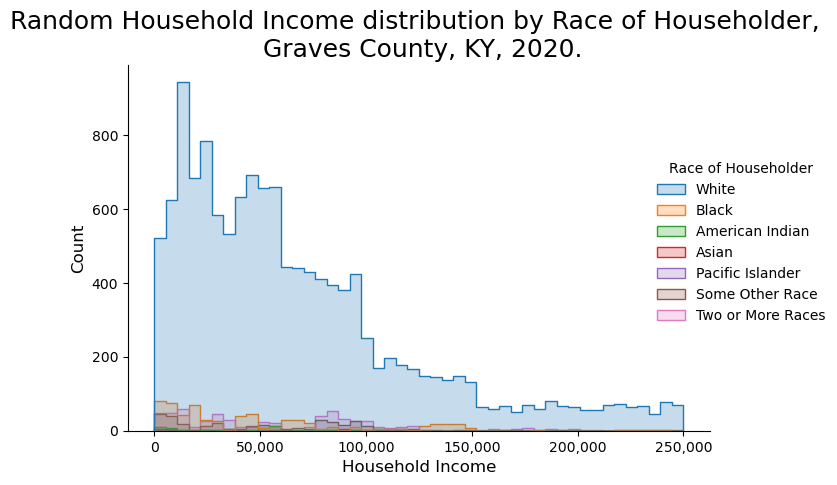

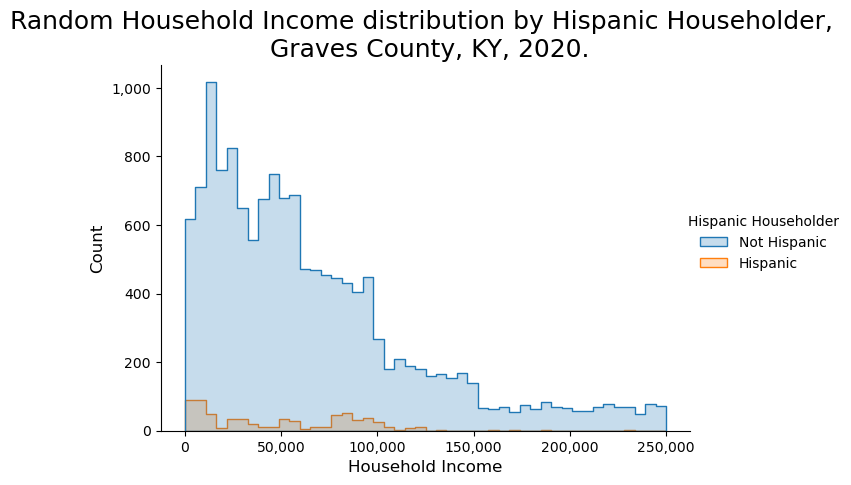

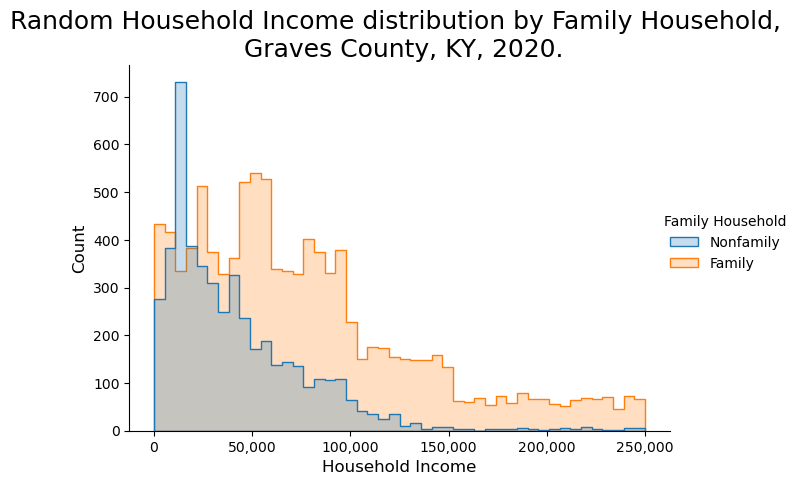

In [28]:
hua_hui_gdf_dict = {}
for basevintage in basevintage_options:
    workflow = process_community_workflow(
                communities,
                seed = 9876,
                version = '2.2.0',
                version_text = 'v2-2-0',
                basevintage = basevintage,
                outputfolder ="OutputData",
                outputfolders = {},
                savefiles = True)
    hua_hui_gdf_dict[basevintage] = workflow.process_communities()

## Run Person Record File

In [29]:
'''
version = '3.0.0'
version_text = 'v3-0-0'

# open, read, and execute python program with reusable commands
from pyncoda.ncoda_07e_generate_prec import generate_prec_functions

# Save Outputfolder - due to long folder name paths output saved to folder with shorter name
# files from this program will be saved with the program name - 
# this helps to follow the overall workflow
outputfolder = "OutputData"
# Make directory to save output
if not os.path.exists(outputfolder):
    os.mkdir(outputfolder)

# Set random seed for reproducibility
seed = 1000
basevintage = 2020

generate_prec_df = generate_prec_functions(
                    communities =   communities,
                    seed =          seed,
                    version =       version,
                    version_text=   version_text,
                    basevintage=    basevintage,
                    outputfolder=   outputfolder
                    )

prec_df = generate_prec_df.generate_prec_v300()
'''

'\nversion = \'3.0.0\'\nversion_text = \'v3-0-0\'\n\n# open, read, and execute python program with reusable commands\nfrom pyncoda.ncoda_07e_generate_prec import generate_prec_functions\n\n# Save Outputfolder - due to long folder name paths output saved to folder with shorter name\n# files from this program will be saved with the program name - \n# this helps to follow the overall workflow\noutputfolder = "OutputData"\n# Make directory to save output\nif not os.path.exists(outputfolder):\n    os.mkdir(outputfolder)\n\n# Set random seed for reproducibility\nseed = 1000\nbasevintage = 2020\n\ngenerate_prec_df = generate_prec_functions(\n                    communities =   communities,\n                    seed =          seed,\n                    version =       version,\n                    version_text=   version_text,\n                    basevintage=    basevintage,\n                    outputfolder=   outputfolder\n                    )\n\nprec_df = generate_prec_df.generate_prec_v

## Explore and Validate Housing Unit Allocation


### Look at population characteristics and compare to US Census

In [30]:
where = communities[community_id]['community_name']
print(where, focalplace, countyname, countyfips)

Mayfield, KY Mayfield Graves County, KY 21083


In [31]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2010'], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","25,634 (93.6%)","6,939 (76.8%)","32,573 (89.4%)"
"2 Black alone, Not Hispanic",567 (2.1%),961 (10.6%),"1,528 (4.2%)"
"3 American Indian and Alaska Native alone, Not Hispanic",50 (0.2%),19 (0.2%),69 (0.2%)
"4 Asian alone, Not Hispanic",54 (0.2%),23 (0.3%),77 (0.2%)
"5 Other Race, Not Hispanic",168 (0.6%),101 (1.1%),269 (0.7%)
"6 Any Race, Hispanic",917 (3.3%),991 (11.0%),"1,908 (5.2%)"
Total,"27,390 (100.0%)","9,034 (100.0%)","36,424 (100.0%)"


In [32]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2010'], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2020',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","25,634 (93.6%)","6,939 (76.8%)","32,573 (89.4%)"
"2 Black alone, Not Hispanic",567 (2.1%),961 (10.6%),"1,528 (4.2%)"
"3 American Indian and Alaska Native alone, Not Hispanic",50 (0.2%),19 (0.2%),69 (0.2%)
"4 Asian alone, Not Hispanic",54 (0.2%),23 (0.3%),77 (0.2%)
"5 Other Race, Not Hispanic",168 (0.6%),101 (1.1%),269 (0.7%)
"6 Any Race, Hispanic",917 (3.3%),991 (11.0%),"1,908 (5.2%)"
Total,"27,390 (100.0%)","9,034 (100.0%)","36,424 (100.0%)"


In [33]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2010'], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010',
                  row_index = "Race Ethnicity",
                  col_index = 'Hispanic')

Hispanic,0. Not Hispanic or Latino (%),1. Hispanic or Latino (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","32,573 (94.4%)",nan (nan%),"32,573 (89.4%)"
"2 Black alone, Not Hispanic","1,528 (4.4%)",nan (nan%),"1,528 (4.2%)"
"3 American Indian and Alaska Native alone, Not Hispanic",69 (0.2%),nan (nan%),69 (0.2%)
"4 Asian alone, Not Hispanic",77 (0.2%),nan (nan%),77 (0.2%)
"5 Other Race, Not Hispanic",269 (0.8%),nan (nan%),269 (0.7%)
"6 Any Race, Hispanic",nan (nan%),"1,908 (100.0%)","1,908 (5.2%)"
Total,"34,516 (100.0%)","1,908 (100.0%)","36,424 (100.0%)"


In [34]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2020'], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2020',
                  row_index = "Race Ethnicity",
                  col_index = 'Hispanic')

Hispanic,0. Not Hispanic or Latino (%),1. Hispanic or Latino (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","30,971 (91.8%)",nan (nan%),"30,971 (85.8%)"
"2 Black alone, Not Hispanic","1,436 (4.3%)",nan (nan%),"1,436 (4.0%)"
"3 American Indian and Alaska Native alone, Not Hispanic",76 (0.2%),nan (nan%),76 (0.2%)
"4 Asian alone, Not Hispanic",126 (0.4%),nan (nan%),126 (0.3%)
"5 Other Race, Not Hispanic","1,140 (3.4%)",nan (nan%),"1,140 (3.2%)"
"6 Any Race, Hispanic",nan (nan%),"2,343 (100.0%)","2,343 (6.5%)"
Total,"33,749 (100.0%)","2,343 (100.0%)","36,092 (100.0%)"


In [35]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2010'], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2010',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$41,376","$30,867","$38,686"
"2 Black alone, Not Hispanic","$32,354","$22,180","$25,875"
"3 American Indian and Alaska Native alone, Not Hispanic","$42,668","$84,556","$52,029"
"4 Asian alone, Not Hispanic","$101,212","$110,613","$106,730"
"5 Other Race, Not Hispanic","$37,997","$29,336","$30,577"
"6 Any Race, Hispanic","$23,103","$24,816","$23,901"
Total,"$40,659","$29,414","$37,476"


In [36]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2020'], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2020',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$55,390","$46,700","$53,446"
"2 Black alone, Not Hispanic","$42,634","$27,160","$29,225"
"3 American Indian and Alaska Native alone, Not Hispanic","$53,586","$49,803","$52,561"
"4 Asian alone, Not Hispanic","$76,758","$22,878","$58,259"
"5 Other Race, Not Hispanic","$67,503","$46,724","$55,616"
"6 Any Race, Hispanic","$38,178","$44,878","$40,915"
Total,"$54,905","$45,084","$52,316"


#### Validate the Housing Unit Allocation has worked
Notice that the population count totals for the community
should match (pretty closely) data collected for the 2010 Decennial Census.
This can be confirmed by going to data.census.gov

In [37]:
print("Total Population by Race and Ethnicity:")
print(f"https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=DECENNIALSF12010.P5")

print("Median Income by Race and Ethnicity:")
print(f"All Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013")
print(f"Black Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013B")
print(f"White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013H")
print(f"Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013I")

Total Population by Race and Ethnicity:
https://data.census.gov/cedsci/table?g=050XX00US21083&tid=DECENNIALSF12010.P5
Median Income by Race and Ethnicity:
All Households: https://data.census.gov/cedsci/table?g=050XX00US21083&tid=ACSDT5Y2012.B19013
Black Households: https://data.census.gov/cedsci/table?g=050XX00US21083&tid=ACSDT5Y2012.B19013B
White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US21083&tid=ACSDT5Y2012.B19013H
Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US21083&tid=ACSDT5Y2012.B19013I


Differences in the housing unit allocation and the Census count may be due to differences between political boundaries and the building inventory. See Rosenheim et al 2019 for more details.

The housing unit allocation, plus the building results will become the input for the social science models such as the population dislocation model.

## Explore Maps

In [38]:
focalplace = 'Brighton'

hua_hui_race_gdf_dict = {}
county_hua_gdf_dict = {}
focal_place_hua_gdf_dict = {}


[nan, nan] [nan, nan]


ValueError: Axis limits cannot be NaN or Inf

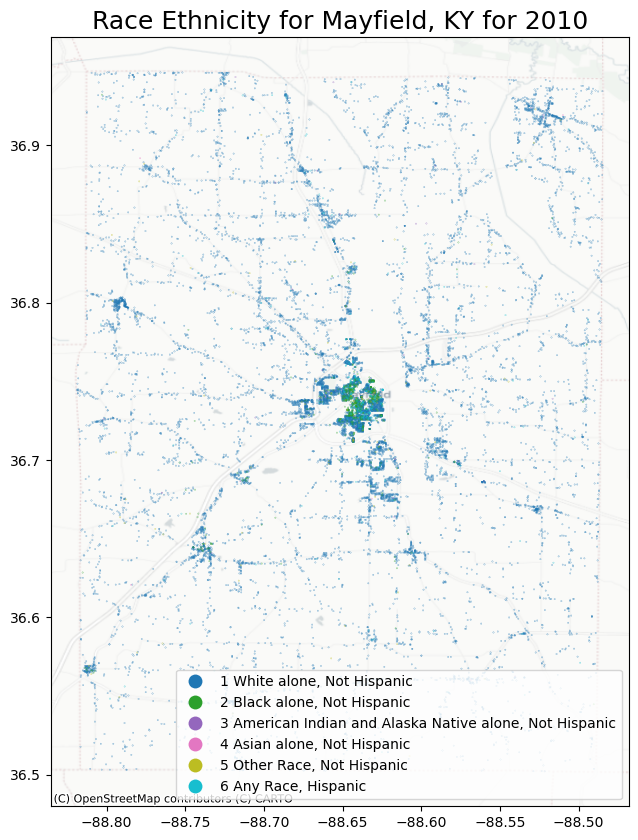

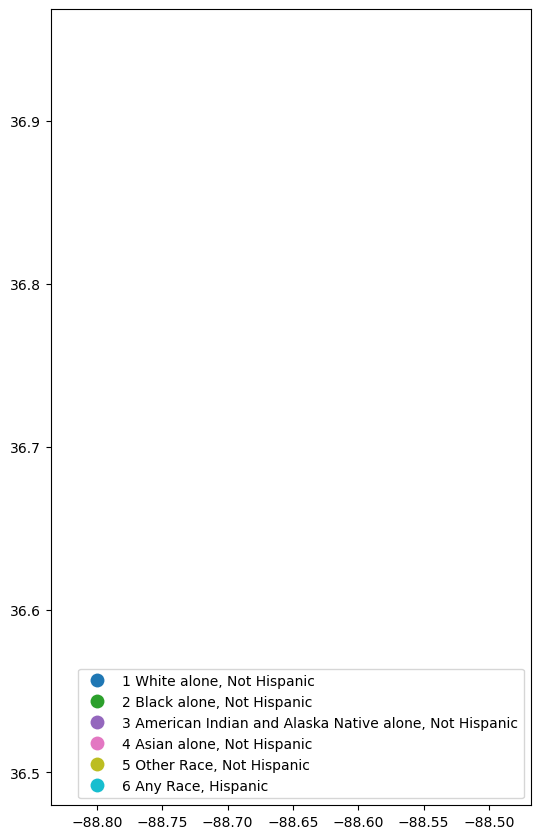

In [39]:
from pyncoda.ncoda_04b_foliummaps import *
# plot png file
from IPython.display import Image

for year in ['2010','2020']:
    # add race ethnicity to data frame for better map legends
    hua_hui_race_gdf_dict[year] = PopResultsTable.add_race_ethnicity_to_pop_df(hua_hui_gdf_dict[year])

    #mapname = 'hhincdotmap'
    mapname = f'hhracedotmap_{year}'
    # Map column
    #map_var = 'Household Income Group'
    map_var = 'Race Ethnicity'
    place = focalplace

    yr = str(year)[2:4]
    condition1 = "(hua_hui_race_gdf_dict[year].race >= 1)"
    condition2 = f"(hua_hui_race_gdf_dict[year].placeNAME{yr} == '{place}')"
    conditions = f"{condition1} & {condition2}"

    county_hua_gdf_dict[year] = hua_hui_race_gdf_dict[year].loc[eval(condition1)].copy(deep=True)
    county_hua_gdf_dict[year] = county_hua_gdf_dict[year].to_crs(epsg=4326)
    focal_place_hua_gdf_dict[year] = hua_hui_race_gdf_dict[year].loc[eval(conditions)].copy(deep=True)
    focal_place_hua_gdf_dict[year] = focal_place_hua_gdf_dict[year].to_crs(epsg=4326)

    bldg_inv_id = communities[community_id]['building_inventory']['id']
    outputfolder = 'OutputData'
    community = communities[community_id]['community_name']

    county_map = plot_dotmap_map(gdf=county_hua_gdf_dict[year],
                            mapname=mapname,
                            map_var=map_var,
                            bldg_inv_id=bldg_inv_id,
                            community=community_id,
                            place = community,
                            year = year,
                            outputfolder=outputfolder,
                            condition_id = "1",
                            basemap_source = cx.providers.CartoDB.Positron)
    
    # get xlim and ylim for focal place
    xlim = [focal_place_hua_gdf_dict[year].total_bounds[0], focal_place_hua_gdf_dict[year].total_bounds[2]]
    ylim = [focal_place_hua_gdf_dict[year].total_bounds[1], focal_place_hua_gdf_dict[year].total_bounds[3]]
    print(xlim, ylim)

    focal_place_map = plot_dotmap_map(gdf=county_hua_gdf_dict[year],
                        mapname=mapname,
                        map_var=map_var,
                        bldg_inv_id=bldg_inv_id,
                        community=community_id,
                        place = focalplace,
                        year = year,
                        outputfolder=outputfolder,
                        condition_id = "2",
                        basemap_source = cx.providers.CartoDB.Positron,
                        xlim = xlim,
                        ylim = ylim,
                        focal_gdf = focal_place_hua_gdf_dict[year])

In [ ]:
# Make an animated GIF from the PNG images
from PIL import Image

# File paths for the PNG images
image1 = 'OutputData/Adams_County_CO_NSI/06_Explore/hhracedotmap_2010_Adams_County_CO_NSI_2_NSI.png'
image2 = 'OutputData/Adams_County_CO_NSI/06_Explore/hhracedotmap_2020_Adams_County_CO_NSI_2_NSI.png'
png_files = [image1, image2]

# Open the images
images = [Image.open(png) for png in png_files]

# Save as an animated GIF
output_gif = 'OutputData/animated_map.gif'
images[0].save(
    output_gif,
    save_all=True,
    append_images=images[1:],  # Add the other images
    duration=1000,  # Duration for each frame in milliseconds
    loop=0  # Loop forever (set to 1 for a single loop)
)

## View Codebook
The Housing Unit Allocation methodology generates a codebook for the housing unit inventory.

Look in the OutputData folder to find the codebook.